### Example: Iris dataset


Cargar el dataset


In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Agregamos el target real al DataFrame para comparar con los clusters obtenidos
df["target"] = iris.target
#Print los target names de las diferentes especies de flor de iris.
print(iris.target_names)


['setosa' 'versicolor' 'virginica']


## Análisis exploratorio básico

Visualización de las primeras y últimas filas

Tipos de datos de las columnas.

Estadísticas descriptivas

Presencia de valores nulos

In [2]:
print("============= Primeras filas del DataFrame ============= \n")
print(df.head())

print(" \n============= Últimas filas del DataFrame ============= \n")
print(df.tail())

print("\n============= Información del dataset y Tipos de datos ============= \n")
print(df.info())

print("\n============= Estadísticas descriptivas ============= \n")
print(df.describe())

print("\n============= Valores nulos ============= \n")
print(df.isnull().sum())

============= Primeras filas del DataFrame ============= 

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
 
============= Últimas filas del DataFrame ============= 

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148       

## Limpieza y Preparación de Datos

No requerido



## Aplicación de K-Means:

Utiliza el algoritmo K-Means para agrupar los datos del dataset Iris basándote en sus características.

Define el número de clusters y visualiza los clusters resultantes.

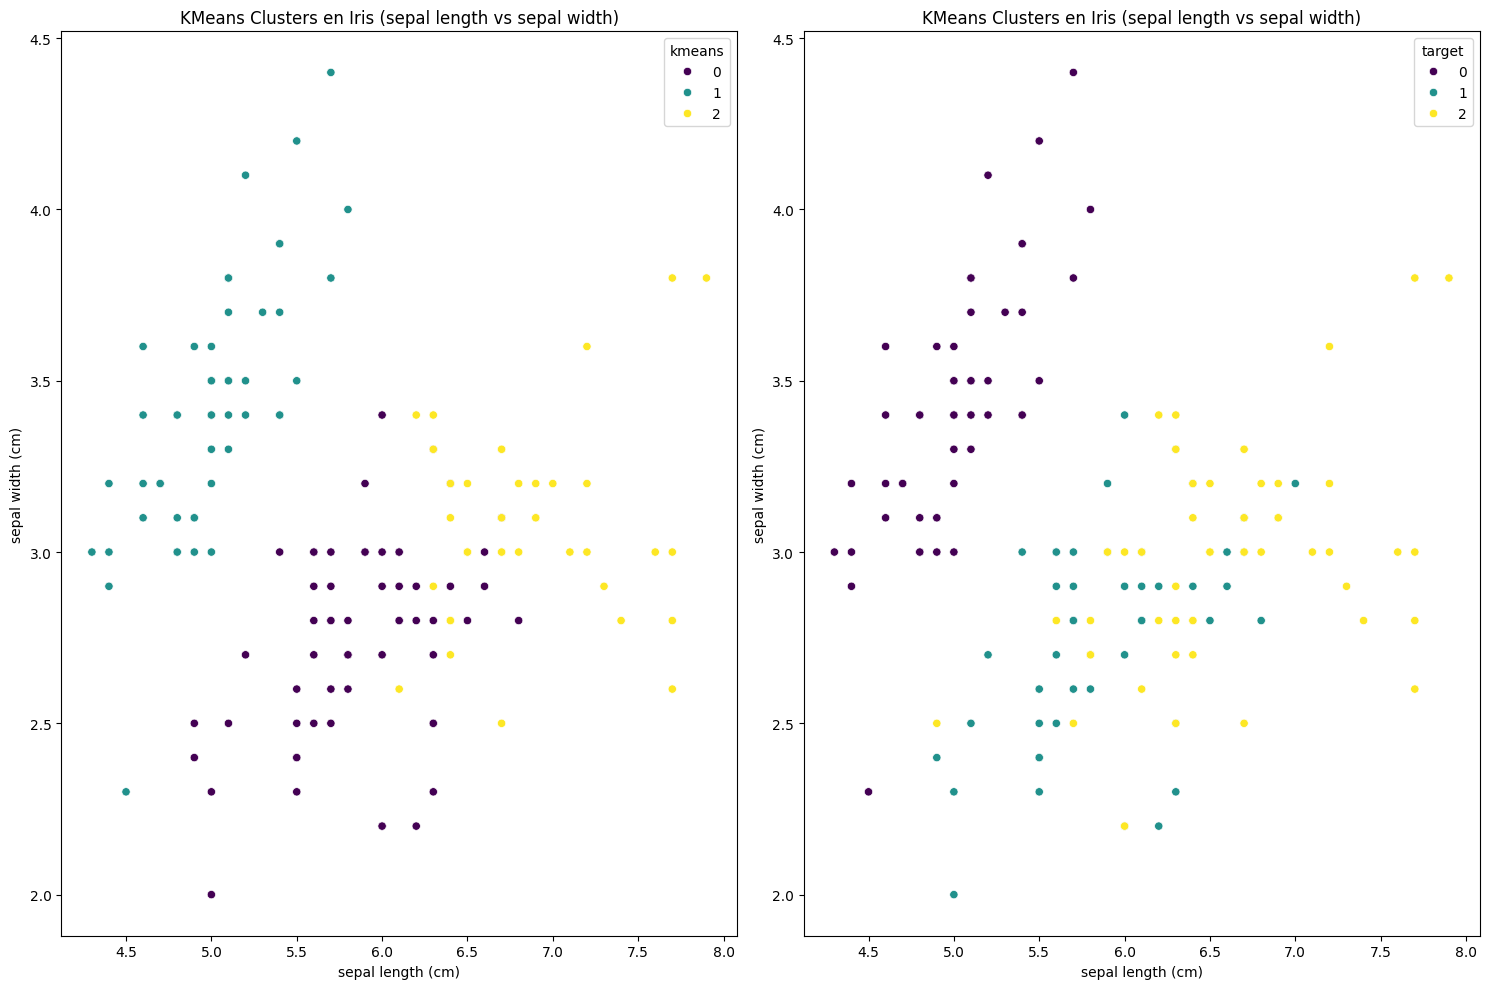

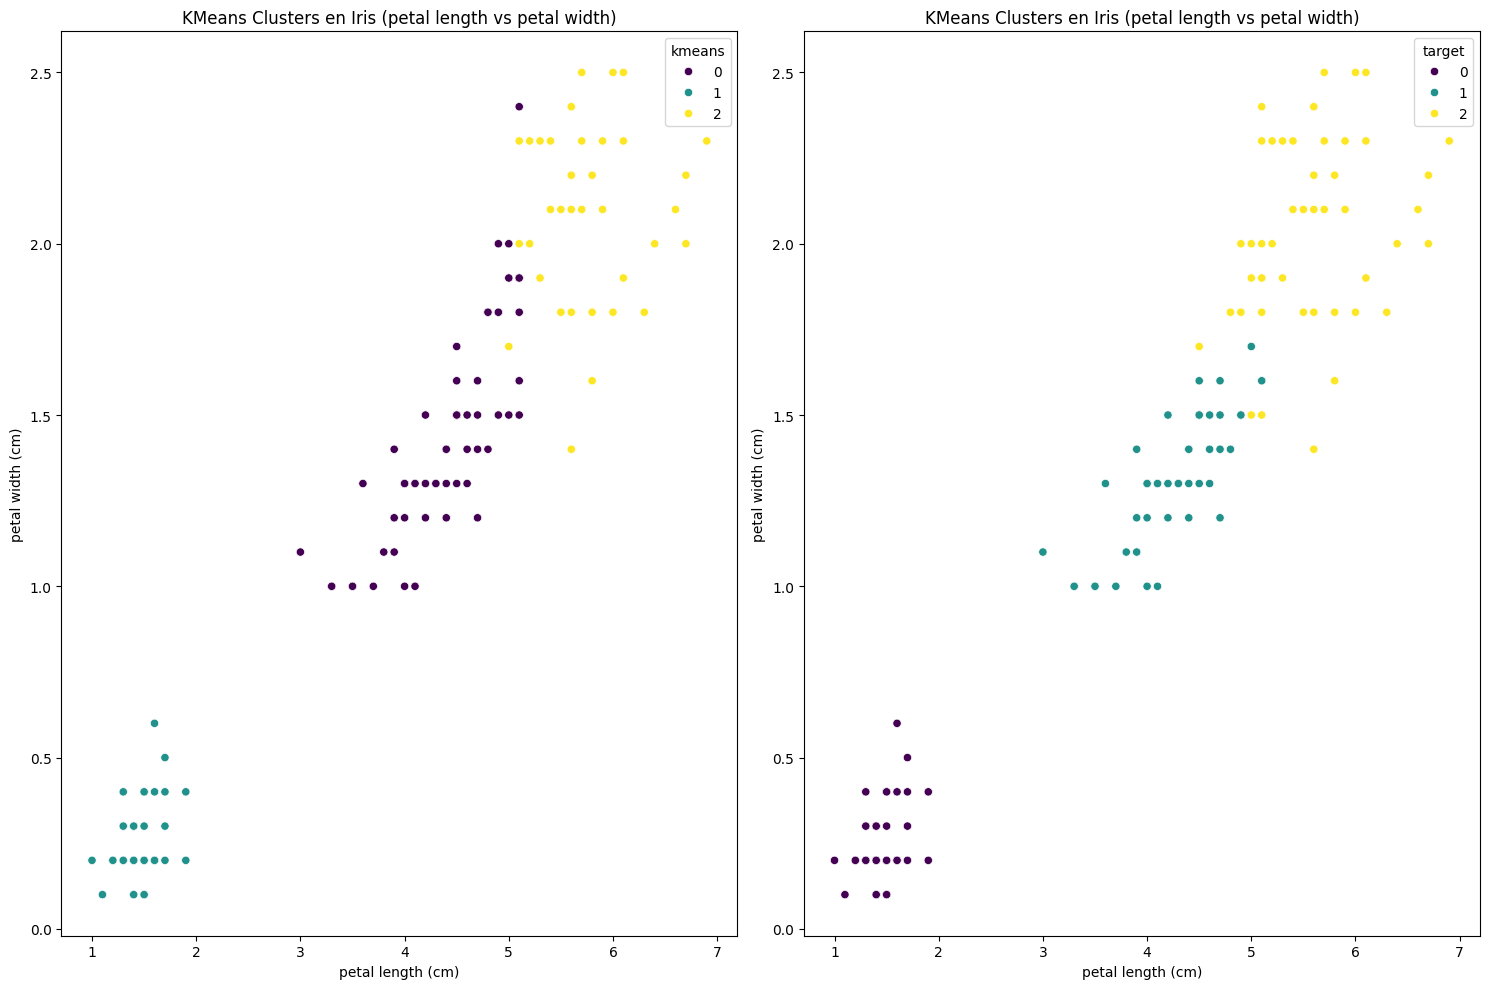

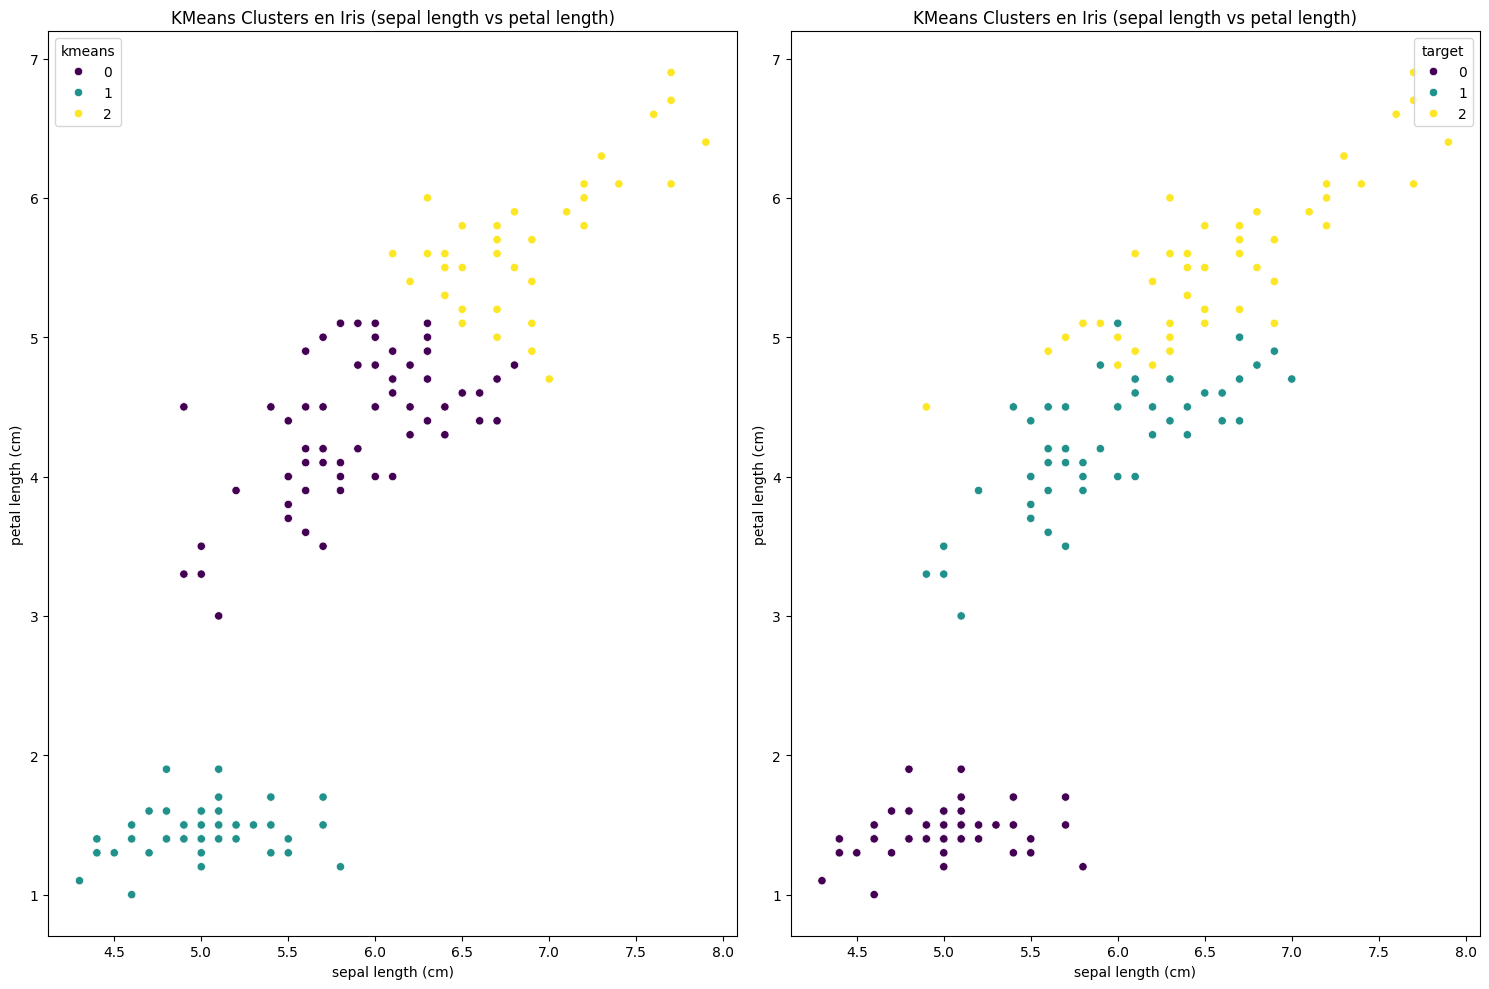

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicamos KMeans para agrupar las flores en 3 clusters (ya que sabemos que hay 3 especies en el dataset)
kmeans = KMeans(n_clusters=3).fit_predict(iris.data)#Fit->Entrenar el modelo ;Predict->Hacer la prediccion
df['kmeans'] = kmeans

#Graficamos los clusters obtenidos por KMeans basándonos en las características 'sepal length (cm)' y 'sepal width (cm)'
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='kmeans', data=df, palette='viridis', legend='full',ax =ax[0])
ax[0].set_title('KMeans Clusters en Iris (sepal length vs sepal width)')
ax[0].set_xlabel('sepal length (cm)')
ax[0].set_ylabel('sepal width (cm)')
#Comparamos con los datos reales de las especies de iris
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='target', data=df, palette='viridis', legend='full',ax =ax[1])
ax[1].set_title('KMeans Clusters en Iris (sepal length vs sepal width)')
ax[1].set_xlabel('sepal length (cm)')
ax[1].set_ylabel('sepal width (cm)')
plt.tight_layout()
plt.show()

#Graficamos los clusters obtenidos por KMeans basándonos en las características 'petal length (cm)' y 'petal width (cm)'
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='kmeans', data=df, palette='viridis', legend='full',ax =ax[0])
ax[0].set_title('KMeans Clusters en Iris (petal length vs petal width)')
ax[0].set_xlabel('petal length (cm)')
ax[0].set_ylabel('petal width (cm)')
#Comparamos con los datos reales de las especies de iris
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='target', data=df, palette='viridis', legend='full',ax =ax[1])
ax[1].set_title('KMeans Clusters en Iris (petal length vs petal width)')
ax[1].set_xlabel('petal length (cm)')
ax[1].set_ylabel('petal width (cm)')
plt.tight_layout()
plt.show()

#Graficamos los clusters obtenidos por KMeans basándonos en las características 'sepal length (cm)' y 'petal length (cm)'
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
sns.scatterplot(x='sepal length (cm)', y='petal length (cm)', hue='kmeans', data=df, palette='viridis', legend='full',ax =ax[0])
ax[0].set_title('KMeans Clusters en Iris (sepal length vs petal length)')
ax[0].set_xlabel('sepal length (cm)')
ax[0].set_ylabel('petal length (cm)')
#Comparamos con los datos reales de las especies de iris
sns.scatterplot(x='sepal length (cm)', y='petal length (cm)', hue='target', data=df, palette='viridis', legend='full',ax =ax[1])
ax[1].set_title('KMeans Clusters en Iris (sepal length vs petal length)')
ax[1].set_xlabel('sepal length (cm)')
ax[1].set_ylabel('petal length (cm)')
plt.tight_layout()
plt.show()

La especie Iris setosa (Grupo 0) presenta la mayor diferenciación morfológica, lo que permite que el algoritmo k-mean la identifique consistentemente como un clúster aislado. Por el contrario, la similitud entre versicolor y virginica genera que sus clústeres, aunque distinguibles, presenten un solapamiento que puede inducir a errores de clasificación en ejemplares específicos. La longitud del pétalo y la longitud del sépalo constituyen las variables óptimas para la segmentación, dado que maximizan la separación entre clústeres y minimizan su solapamiento.

## Comparación de Algoritmos de Clustering

Aplica al menos dos algoritmos de clustering distintos (por ejemplo, K-Means y GMM) al mismo dataset.

Compara los resultados de los diferentes algoritmos utilizando métricas y visualiza los clusters formados.

Métricas de KMeans:
Silhouette Score: 0.5512
Adjusted Rand Index (ARI): 0.7163
Normalized Mutual Info (NMI): 0.7419

Métricas de GMM:
Silhouette Score: 0.5012
Adjusted Rand Index (ARI): 0.9039
Normalized Mutual Info (NMI): 0.8997


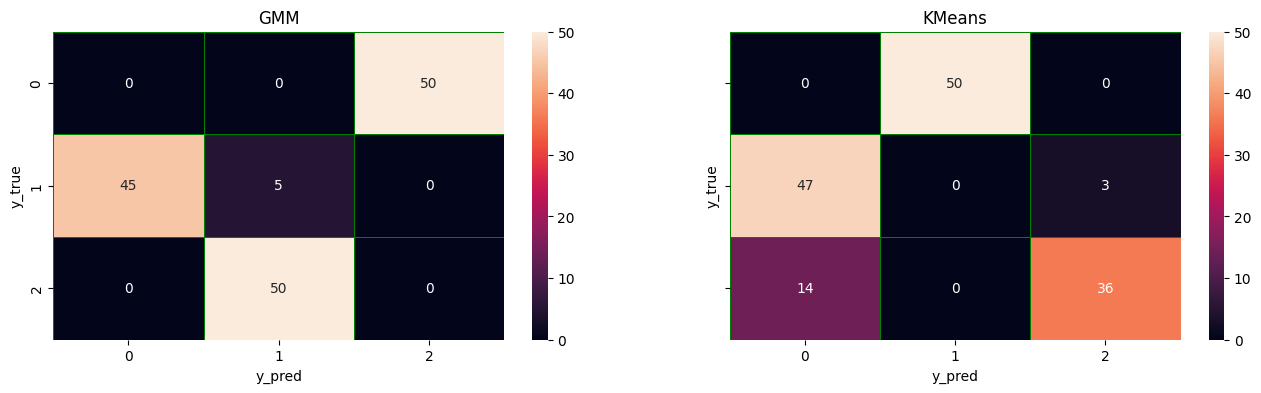

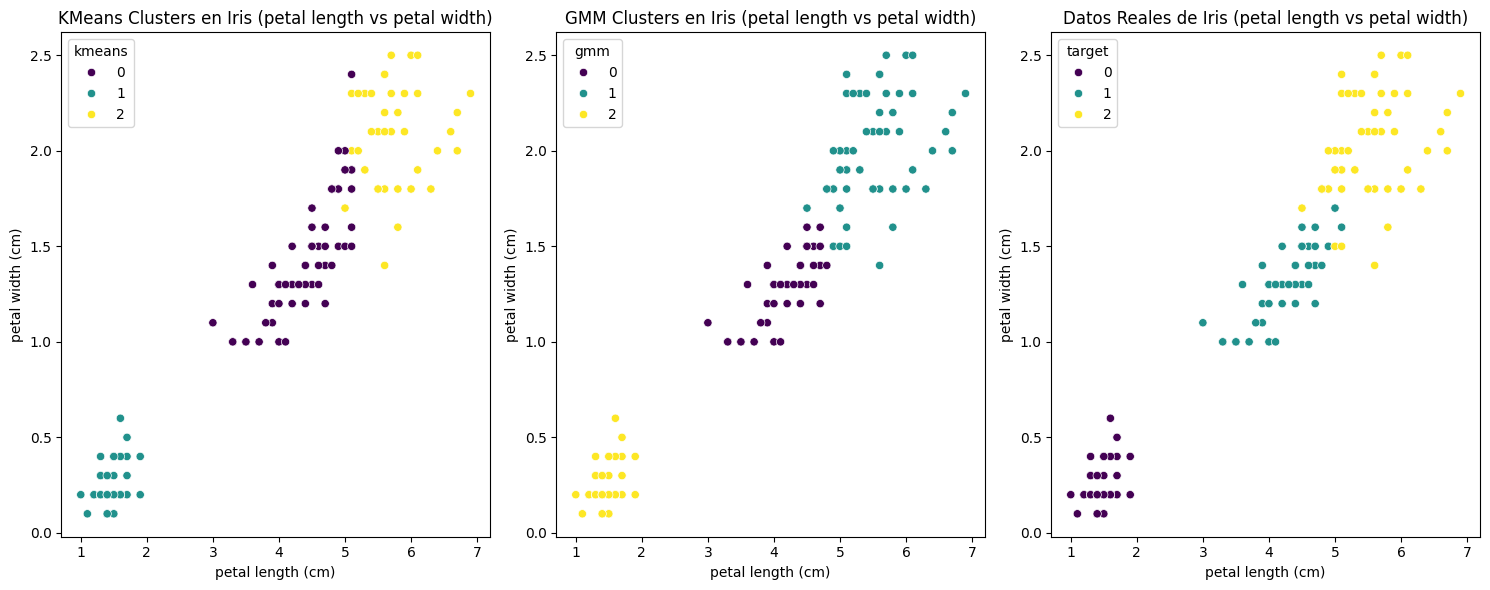

In [15]:
from sklearn import mixture
from sklearn.metrics import adjusted_rand_score, adjusted_rand_score, confusion_matrix, normalized_mutual_info_score, silhouette_score 

gmm = mixture.GaussianMixture(n_components=3,covariance_type='full')
df['gmm'] = gmm.fit_predict(iris.data)

# Métricas
# KMeans
km_silhouette = silhouette_score(iris.data, df['kmeans'])
km_ari = adjusted_rand_score(df['target'], df['kmeans'])
km_nmi = normalized_mutual_info_score(df['target'], df['kmeans'])

# GMM
gmm_silhouette = silhouette_score(iris.data, df['gmm'])
gmm_ari = adjusted_rand_score(df['target'], df['gmm'])
gmm_nmi = normalized_mutual_info_score(df['target'], df['gmm'])

print("Métricas de KMeans:")
print(f"Silhouette Score: {km_silhouette:.4f}") #Ideal = 1, peor = -1 Implica que los clusters están bien separados y son compactos. Un valor cercano a 1 indica que los clusters están bien definidos, mientras que un valor cercano a -1 sugiere que los clusters se superponen o están mal definidos.
print(f"Adjusted Rand Index (ARI): {km_ari:.4f}")#Ideal = 1, peor = 0. Implica que los clusters obtenidos por el algoritmo coinciden perfectamente con las etiquetas reales. Un valor cercano a 1 indica una alta concordancia entre los clusters y las etiquetas reales, mientras que un valor cercano a 0 sugiere que la asignación de clusters es aleatoria.
print(f"Normalized Mutual Info (NMI): {km_nmi:.4f}\n")#Ideal = 1, peor = 0. Implica que los clusters obtenidos por el algoritmo comparten toda la información con las etiquetas reales. Un valor cercano a 1 indica que los clusters y las etiquetas reales están altamente relacionados, mientras que un valor cercano a 0 sugiere que no hay relación entre los clusters y las etiquetas reales.

print("Métricas de GMM:")
print(f"Silhouette Score: {gmm_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {gmm_ari:.4f}")
print(f"Normalized Mutual Info (NMI): {gmm_nmi:.4f}")


cm1 = confusion_matrix(df['target'], df['gmm'])
cm2 = confusion_matrix(df['target'], df['kmeans'])

fig, ax = plt.subplots(1, 2, figsize=(16, 4),sharey=True)

sns.heatmap(cm1,annot = True,linewidths=0.5,linecolor="green",fmt = ".0f",ax=ax[0])
ax[0].set_xlabel("y_pred")
ax[0].set_ylabel("y_true")
ax[0].set_title('GMM')

sns.heatmap(cm2,annot = True,linewidths=0.5,linecolor="green",fmt = ".0f",ax=ax[1])
ax[1].set_xlabel("y_pred")
ax[1].set_ylabel("y_true")
ax[1].set_title('KMeans')

#Graficamos los clusters obtenidos por KMeans basándonos en las características 'petal length (cm)' y 'petal width (cm)'
fig, ax = plt.subplots(1, 3, figsize=(15, 6))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='kmeans', data=df, palette='viridis', legend='full',ax =ax[0])
ax[0].set_title('KMeans Clusters en Iris (petal length vs petal width)')
ax[0].set_xlabel('petal length (cm)')
ax[0].set_ylabel('petal width (cm)')
#Graficamos los clusters obtenidos por GMM basándonos en las características 'petal length (cm)' y 'petal width (cm)'
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='gmm', data=df, palette='viridis', legend='full',ax =ax[1])
ax[1].set_title('GMM Clusters en Iris (petal length vs petal width)')
ax[1].set_xlabel('petal length (cm)')
ax[1].set_ylabel('petal width (cm)')
#Comparamos con los datos reales de las especies de iris
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='target', data=df, palette='viridis', legend='full',ax =ax[2])
ax[2].set_title('Datos Reales de Iris (petal length vs petal width)')
ax[2].set_xlabel('petal length (cm)')
ax[2].set_ylabel('petal width (cm)')
plt.tight_layout()
plt.show()

El algoritmo GMM obtiene mejores resultados en ARI y NMI (valores cercanos a 1), evidenciando una alta concordancia con las etiquetas reales. El coeficiente de Silhouette es similar en ambos modelos (~0.5), lo que indica una separación y compacidad moderadas. Esto se ve reflejado en la formación de clusters elípticos causados por las variaciones morfológicas presentes en las clases versicolor y virginica.

Atendiendo a las matrices de confución, ambos métodos identifican correctamente el 100% de la clase 0 (setosa). No obstante, el algoritmo GMM es superior en la distinción de las clases 1 (versicolor) y 2 (virginica), registrando solo 5 errores .

En contraste, K-means presenta un desempeño inferior con 17 errores de clasificación